# ML Pipeline - Student's Performance 

This notebook builds and evaluates regression and classification models
for predicting student exam performance and distinction status.

The pipeline progresses from simple baselines to linear/logistic regression,
decision trees, and random forests. Models are evaluated on a fixed
train/test split using appropriate metrics, followed by error analysis
and calibration.

All random operations use fixed seeds so the analysis is reproducible.

## Libraries import and Dataset

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import calibration_curve

In [75]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})


In [76]:
students 

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0
...,...,...,...,...,...,...
595,596,A,11.6,6.0,100.0,100.0
596,597,A,10.0,9.1,72.0,80.7
597,598,B,14.9,6.6,90.1,96.7
598,599,C,7.5,7.0,95.6,86.9


In [77]:
print(students.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             600 non-null    int64  
 1   class_section          600 non-null    object 
 2   study_hours_per_week   600 non-null    float64
 3   sleep_hours_per_night  600 non-null    float64
 4   attendance_pct         600 non-null    float64
 5   exam_score             600 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 28.2+ KB
None


In [78]:
print(students.isnull().sum())

student_id               0
class_section            0
study_hours_per_week     0
sleep_hours_per_night    0
attendance_pct           0
exam_score               0
dtype: int64


In [79]:
print(students.describe())

       student_id  study_hours_per_week  sleep_hours_per_night  \
count  600.000000            600.000000             600.000000   
mean   300.500000             10.089333               7.046000   
std    173.349358              3.407213               1.122787   
min      1.000000              0.400000               3.400000   
25%    150.750000              7.700000               6.275000   
50%    300.500000             10.000000               7.100000   
75%    450.250000             12.500000               7.800000   
max    600.000000             21.900000              10.000000   

       attendance_pct  exam_score  
count      600.000000  600.000000  
mean        85.583000   88.605000  
std          9.137597   10.205279  
min         62.000000   58.900000  
25%         78.900000   81.750000  
50%         85.700000   90.200000  
75%         92.325000   98.700000  
max        100.000000  100.000000  


## Feature engineering (one-hot encode class_section)

In [80]:
X = pd.get_dummies(students[["study_hours_per_week", "sleep_hours_per_night",
                              "attendance_pct", "class_section"]],
                    columns=["class_section"], drop_first=True)
y = students["exam_score"]

print(X.columns.tolist())
print(X.shape)

['study_hours_per_week', 'sleep_hours_per_night', 'attendance_pct', 'class_section_B', 'class_section_C']
(600, 5)


## Split once with a fixed seed

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(480, 5) (120, 5)


## Regression Baseline 


In [82]:
baseline_reg = DummyRegressor(strategy="mean")
baseline_reg.fit(X_train, y_train)

baseline_preds = baseline_reg.predict(X_test)
baseline_rmse = mean_squared_error(y_test, baseline_preds) ** 0.5
baseline_r2 = r2_score(y_test, baseline_preds)

print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²: {baseline_r2:.4f}")

Baseline RMSE: 10.30
Baseline R²: -0.0096


## Real Linear Regression

In [83]:
model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

rmse = mean_squared_error(y_test, preds) ** 0.5
r2 = r2_score(y_test, preds)

print(f"Model RMSE: {rmse:.2f}")
print(f"Model R²: {r2:.4f}")
print(f"Improvement over baseline: RMSE dropped by {baseline_rmse - rmse:.2f}, "
      f"R² improved from {baseline_r2:.4f} to {r2:.4f}")

Model RMSE: 7.06
Model R²: 0.5257
Improvement over baseline: RMSE dropped by 3.24, R² improved from -0.0096 to 0.5257


In [84]:
improvement_rmse = baseline_rmse - rmse
r2_pct = r2 * 100

summary = (
    f"The linear regression model reduced RMSE from {baseline_rmse:.2f} to {rmse:.2f} "
    f"and improved R² from roughly {baseline_r2:.2f} to {r2:.2f}, meaning it explains "
    f"about {r2_pct:.0f}% of the variance in exam scores."
)
print(summary)

The linear regression model reduced RMSE from 10.30 to 7.06 and improved R² from roughly -0.01 to 0.53, meaning it explains about 53% of the variance in exam scores.


## Coefficients 

In [85]:
for name, coef in zip(X.columns, model.coef_):
    print(f"{name}: {coef:.4f}")

study_hours_per_week: 2.0330
sleep_hours_per_night: -0.0107
attendance_pct: 0.0887
class_section_B: 0.1248
class_section_C: 3.1304


The largest effect comes from class_section_C (+3.13) and study_hours_per_week (+2.03),study hours matters most per hour studied, but Section C gives the single biggest jump for any one feature. Both match Monday: study hours had a strong correlation with exam score (r = 0.69), and Section C's edge over Section A (91.36 vs 87.61) was confirmed by a bootstrap CI that excluded zero. Sleep hours barely mattered in either near-zero correlation on Monday (r = -0.02) and a near-zero coefficient today (-0.0107).

## Classification target and class balance check

In [86]:
students["distinction"] = (students["exam_score"] >= 85).astype(int)
distinction_rate = students["distinction"].mean()
print(f"Fraction with distinction: {distinction_rate:.4f}")

Fraction with distinction: 0.6533


In [87]:
print(f"About {distinction_rate * 100:.4f}% of students hit the threshhold")

About 65.3333% of students hit the threshhold


In [88]:
print(students["distinction"].value_counts())

distinction
1    392
0    208
Name: count, dtype: int64


## Classification Baseline

In [89]:
y_clf = students["distinction"]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

baseline_clf = DummyClassifier(strategy="most_frequent")
baseline_clf.fit(Xc_train, yc_train)
base_preds = baseline_clf.predict(Xc_test)

base_acc = accuracy_score(yc_test, base_preds)
base_prec = precision_score(yc_test, base_preds, zero_division=0)
base_rec = recall_score(yc_test, base_preds, zero_division=0)
base_f1 = f1_score(yc_test, base_preds, zero_division=0)

print(f"Accuracy: {base_acc:.4f}, Precision: {base_prec:.4f}, Recall: {base_rec:.4f}, F1: {base_f1:.4f}")

Accuracy: 0.6500, Precision: 0.6500, Recall: 1.0000, F1: 0.7879


In [90]:
summary_baseline = (
    f"The baseline achieved {base_acc * 100:.2f}% accuracy simply by always predicting "
    f"the majority class ('distinction'). Recall "
    f"({base_rec:.2f}) is trivially perfect because a classifier that always says positive can "
    f"never produce a false negative. Precision "
    f"({base_prec * 100:.2f}%) lands exactly on accuracy for the same structural reason: with "
    f"zero negative predictions, TP/(TP+FP) and (TP+TN)/n collapse to the same ratio, the "
    f"positive class's base rate in the test set."
)
print(summary_baseline)

The baseline achieved 65.00% accuracy simply by always predicting the majority class ('distinction'). Recall (1.00) is trivially perfect because a classifier that always says positive can never produce a false negative. Precision (65.00%) lands exactly on accuracy for the same structural reason: with zero negative predictions, TP/(TP+FP) and (TP+TN)/n collapse to the same ratio, the positive class's base rate in the test set.


## Logistic Regression Model

In [91]:
clf_lr = LogisticRegression(random_state=42, max_iter=1000)
clf_lr.fit(Xc_train, yc_train)
clf_lr_preds = clf_lr.predict(Xc_test)

acc = accuracy_score(yc_test, clf_lr_preds)
prec = precision_score(yc_test, clf_lr_preds, zero_division=0)
rec = recall_score(yc_test, clf_lr_preds, zero_division=0)
f1 = f1_score(yc_test, clf_lr_preds, zero_division=0)

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

Accuracy: 0.7667, Precision: 0.8125, Recall: 0.8333, F1: 0.8228


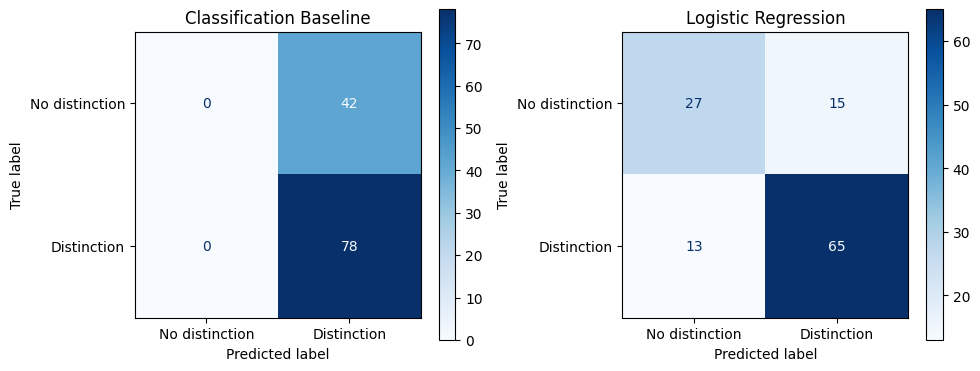

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    yc_test,
    base_preds,
    display_labels=["No distinction", "Distinction"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Classification Baseline")

ConfusionMatrixDisplay.from_predictions(
    yc_test,
    clf_lr_preds,
    display_labels=["No distinction", "Distinction"],
    cmap="Blues",
    ax=axes[1]
)
axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

In [93]:
summary_logistic = (
    f"Logistic regression achieved {acc * 100:.2f}% accuracy, "
    f"{prec * 100:.2f}% precision, {rec * 100:.2f}% recall, "
    f"and {f1 * 100:.2f}% F1 score. Compared with the baseline, "
    f"accuracy increased by {(acc - base_acc) * 100:.2f} percentage points, "
    f"precision increased by {(prec - base_prec) * 100:.2f} percentage points, "
    f"recall decreased by {(base_rec - rec) * 100:.2f} percentage points, "
    f"and F1 score increased by {(f1 - base_f1) * 100:.2f} percentage points."
)

print(summary_logistic)

Logistic regression achieved 76.67% accuracy, 81.25% precision, 83.33% recall, and 82.28% F1 score. Compared with the baseline, accuracy increased by 11.67 percentage points, precision increased by 16.25 percentage points, recall decreased by 16.67 percentage points, and F1 score increased by 3.49 percentage points.


# Decision Tree-Regression

## Unconstrained Decision Tree Regression

In [94]:
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Training performance 
tree_train_preds = tree_reg.predict(X_train)
tree_train_rmse = mean_squared_error(y_train, tree_train_preds) ** 0.5
tree_train_r2 = r2_score(y_train, tree_train_preds)

# Test performance
tree_preds = tree_reg.predict(X_test)
tree_rmse = mean_squared_error(y_test, tree_preds) ** 0.5
tree_r2 = r2_score(y_test, tree_preds)



In [95]:
print(f"Train RMSE: {tree_train_rmse:.2f}, Train R²: {tree_train_r2:.4f}")
print(f"Test  RMSE: {tree_rmse:.2f}, Test  R²: {tree_r2:.4f}")

Train RMSE: 0.00, Train R²: 1.0000
Test  RMSE: 9.84, Test  R²: 0.0782


The unconstrained Decision Tree Regressor achieved a **training RMSE of 0.00 and R² of 1.00**, showing that it nearly perfectly fit the training data. However, its **test RMSE increased to 9.84 and R² dropped to 0.0782**, indicating poor generalization. This large gap between training and test performance demonstrates **clear overfitting**, as the tree has likely memorized noise in the training data rather than learning patterns that generalize well.


## Constrained Decision Tree Regression — max_depth=3

In [96]:
tree_reg_d3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg_d3.fit(X_train, y_train)

tree_d3_preds = tree_reg_d3.predict(X_test)
tree_d3_rmse = mean_squared_error(y_test, tree_d3_preds) ** 0.5
tree_d3_r2 = r2_score(y_test, tree_d3_preds)

tree_d3_train_preds = tree_reg_d3.predict(X_train)
tree_d3_train_rmse = mean_squared_error(y_train, tree_d3_train_preds) ** 0.5
tree_d3_train_r2 = r2_score(y_train, tree_d3_train_preds)

In [97]:
print(f"Train RMSE: {tree_d3_train_rmse:.2f}, Train R²: {tree_d3_train_r2:.4f}")
print(f"Test  RMSE: {tree_d3_rmse:.2f}, Test  R²: {tree_d3_r2:.4f}")

Train RMSE: 7.00, Train R²: 0.5263
Test  RMSE: 7.10, Test  R²: 0.5197


With `max_depth=3`, the Decision Tree showed much better generalization: **Train RMSE = 7.00, R² = 0.5263**, while **Test RMSE = 7.10, R² = 0.5197**. Compared with the unconstrained tree (Test RMSE = 9.84, R² = 0.0782), the shallow tree substantially improved test performance and greatly reduced the train–test gap. This demonstrates how limiting tree depth reduces **overfitting** and improves generalization.


# Decision Tree Classifier

## Unconstrained Decision Tree Classification

In [98]:
## Decision Tree — classification (unconstrained, then depth-3)
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(Xc_train, yc_train)
tree_clf_preds = tree_clf.predict(Xc_test)
print("Unconstrained:", f"Accuracy: {accuracy_score(yc_test, tree_clf_preds)}")
print(f"Precision: {precision_score(yc_test, tree_clf_preds, zero_division=0)}")
print(f"Recall: {recall_score(yc_test, tree_clf_preds, zero_division=0)}")
print(f"F1-Score: {f1_score(yc_test, tree_clf_preds, zero_division=0)}")

Unconstrained: Accuracy: 0.7333333333333333
Precision: 0.8194444444444444
Recall: 0.7564102564102564
F1-Score: 0.7866666666666666


## Constrained Decision Tree Classification — max_depth=3

Depth-3: Accuracy: 0.7416666666666667
Precision: 0.7238095238095238
Recall: 0.9743589743589743
F1-Score: 0.8306010928961749


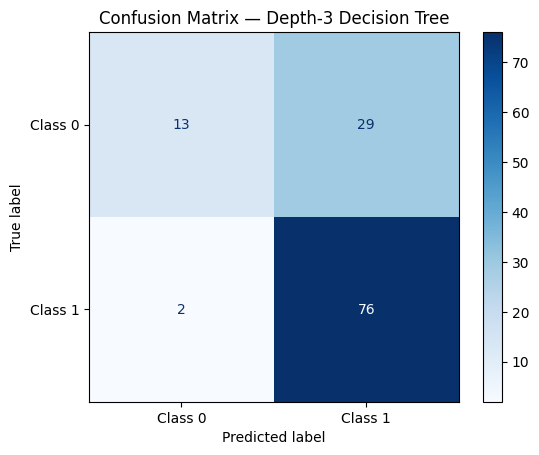

In [99]:
tree_clf_d3 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_d3.fit(Xc_train, yc_train)
tree_clf_d3_preds = tree_clf_d3.predict(Xc_test)
print("Depth-3:",f"Accuracy: {accuracy_score(yc_test, tree_clf_d3_preds)}")
print(f"Precision: {precision_score(yc_test, tree_clf_d3_preds, zero_division=0)}")
print(f"Recall: {recall_score(yc_test, tree_clf_d3_preds, zero_division=0)}")
print(f"F1-Score: {f1_score(yc_test, tree_clf_d3_preds, zero_division=0)}")
ConfusionMatrixDisplay.from_predictions(
    yc_test,
    tree_clf_d3_preds,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues"
)

plt.title("Confusion Matrix — Depth-3 Decision Tree")
plt.show()

# Random Forest-Regression and Classifier

In [100]:
## Random Forest — Regression
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
rf_preds = rf_reg.predict(X_test)
rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_r2 = r2_score(y_test, rf_preds)
print(f"Random Forest — Test RMSE: {rf_rmse:.2f}, Test R²: {rf_r2:.4f}")
for name, imp in sorted(zip(X.columns, rf_reg.feature_importances_), key=lambda x: -x[1]):
    print(f"{name}: {imp:.4f}")

Random Forest — Test RMSE: 7.40, Test R²: 0.4785
study_hours_per_week: 0.6428
attendance_pct: 0.1667
sleep_hours_per_night: 0.1413
class_section_C: 0.0324
class_section_B: 0.0168


Accuracy: 0.7250
Precision: 0.7711
Recall: 0.8205
F1-Score: 0.7950


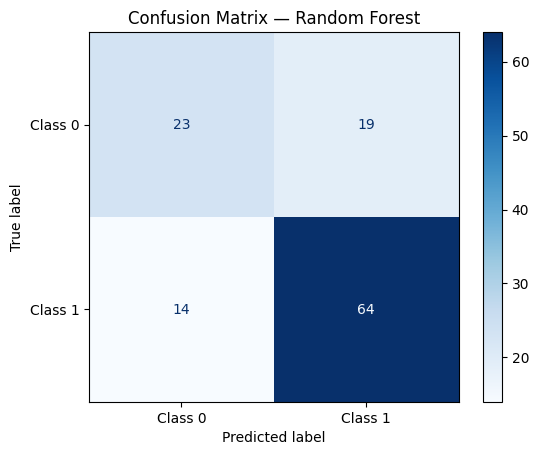

In [101]:
## Random Forest — classification
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(Xc_train, yc_train)
rf_clf_preds = rf_clf.predict(Xc_test)
rf_acc = accuracy_score(yc_test, rf_clf_preds)
rf_prec = precision_score(yc_test, rf_clf_preds, zero_division=0)
rf_rec = recall_score(yc_test, rf_clf_preds, zero_division=0)
rf_f1 = f1_score(yc_test, rf_clf_preds, zero_division=0)
print(f"Accuracy: {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall: {rf_rec:.4f}")
print(f"F1-Score: {rf_f1:.4f}")

ConfusionMatrixDisplay.from_predictions(
    yc_test,
    rf_clf_preds,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues"
)

plt.title("Confusion Matrix — Random Forest")
plt.show()

# Comparison Table

In [102]:
# --- Regression table ---
regression_results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Decision Tree (unconstrained)",
              "Decision Tree (max_depth=3)", "Random Forest"],
    "RMSE": [baseline_rmse, rmse, tree_rmse, tree_d3_rmse, rf_rmse],
    "R²":   [baseline_r2, r2, tree_r2, tree_d3_r2, rf_r2]
})

regression_results.style \
    .format({"RMSE": "{:.2f}", "R²": "{:.4f}"}) \
    .highlight_min(subset=["RMSE"], color="grey") \
    .highlight_max(subset=["R²"], color="grey")

,Model,RMSE,R²
0,Baseline,10.30,-0.0096
1,Linear Regression,7.06,0.5257
2,Decision Tree (unconstrained),9.84,0.0782
3,Decision Tree (max_depth=3),7.10,0.5197
4,Random Forest,7.40,0.4785


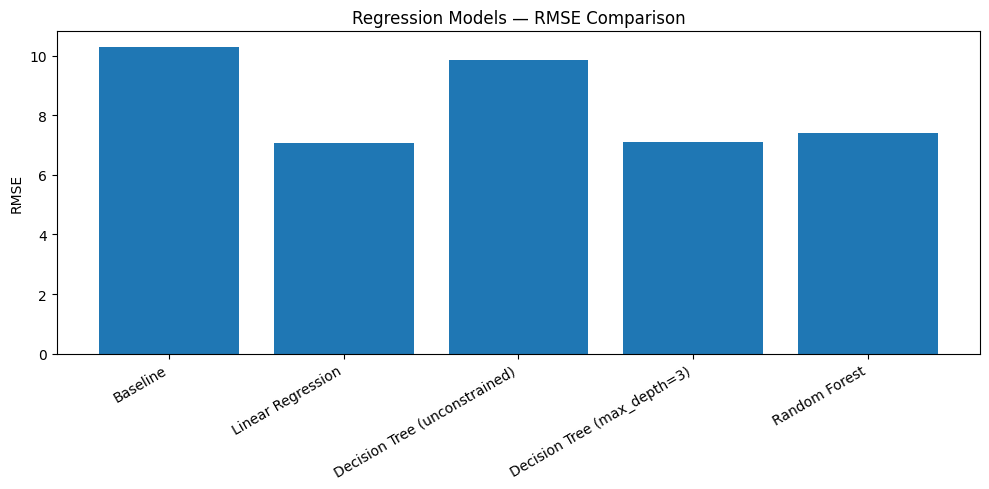

In [103]:
plt.figure(figsize=(10, 5))
plt.bar(regression_results["Model"], regression_results["RMSE"])
plt.ylabel("RMSE")
plt.title("Regression Models — RMSE Comparison")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

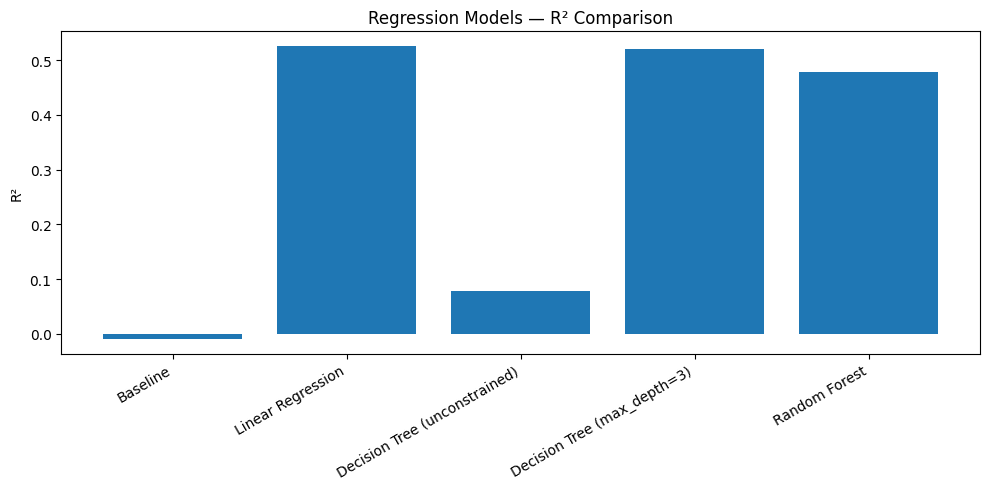

In [104]:
plt.figure(figsize=(10, 5))

plt.bar(regression_results["Model"], regression_results["R²"])

plt.ylabel("R²")
plt.title("Regression Models — R² Comparison")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

Regression verdict: Ship linear regression, it has the lowest RMSE (7.06) and highest R² (0.5257) of every model built, including the forest. This is the "uncomfortable lesson" made literal: the depth-3 tree only ties it (7.10/0.5197), and the random forest nominally the most sophisticated model here , is actually worse (7.40/0.4785) than plain linear regression on this dataset. More trees and more flexibility bought nothing once the tree was already constrained enough to stop overfitting.


In [105]:
# --- Classification table ---
tree_clf_d3_acc = accuracy_score(yc_test, tree_clf_d3_preds)
tree_clf_d3_prec = precision_score(yc_test, tree_clf_d3_preds, zero_division=0)
tree_clf_d3_rec = recall_score(yc_test, tree_clf_d3_preds, zero_division=0)
tree_clf_d3_f1 = f1_score(yc_test, tree_clf_d3_preds, zero_division=0)

classification_results = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Decision Tree (max_depth=3)", "Random Forest"],
    "Accuracy":  [base_acc, acc, tree_clf_d3_acc, rf_acc],
    "Precision": [base_prec, prec, tree_clf_d3_prec, rf_prec],
    "Recall":    [base_rec, rec, tree_clf_d3_rec, rf_rec],
    "F1":        [base_f1, f1, tree_clf_d3_f1, rf_f1]
})

classification_results.style \
    .format({"Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}"}) \
    .highlight_max(subset=["Accuracy", "Precision", "Recall", "F1"], color="grey")

,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.6500,0.6500,1.0000,0.7879
1,Logistic Regression,0.7667,0.8125,0.8333,0.8228
2,Decision Tree (max_depth=3),0.7417,0.7238,0.9744,0.8306
3,Random Forest,0.7250,0.7711,0.8205,0.7950


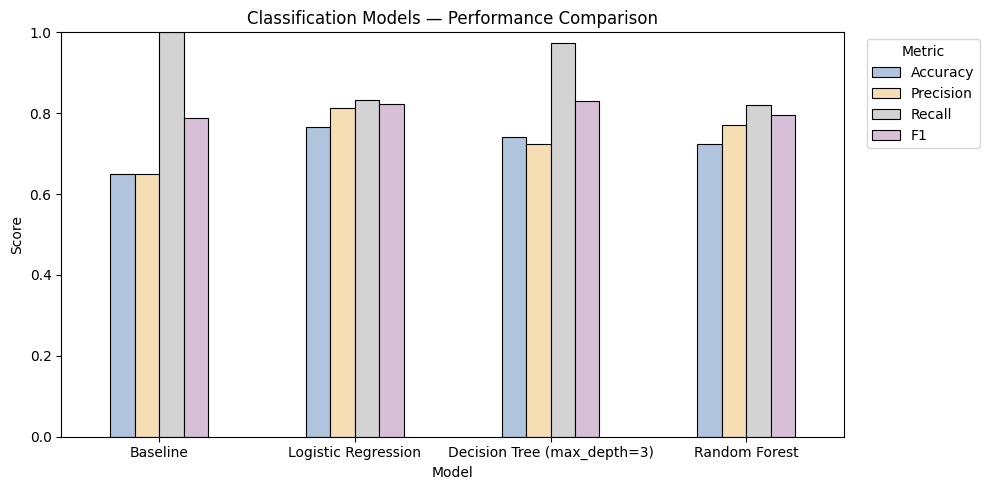

In [106]:
classification_results.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1"],
    kind="bar",
    figsize=(10, 5),
    color=["lightsteelblue", "wheat", "lightgray", "thistle"],
    edgecolor="black",
    linewidth=0.8
)

plt.ylabel("Score")
plt.title("Classification Models — Performance Comparison")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(
    title="Metric",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

I would ship Logistic Regression because its precision/recall trade-off is more balanced and it is simpler to interpret, even though the depth-3 decision tree has a slightly higher F1 score (0.8306 vs. 0.8228). If missing a distinction-worthy student were substantially more costly than generating false positives, I would instead choose the depth-3 decision tree because its recall is 97.44%, compared with 83.33% for Logistic Regression.


# Error Analysis 

In [107]:
## Error analysis, regression (linear regression)

residuals = y_test - preds  # preds = linear regression predictions
abs_residuals = residuals.abs()

worst_idx = abs_residuals.sort_values(ascending=False).head(5).index

worst_reg = X_test.loc[worst_idx].copy()
worst_reg["actual"] = y_test.loc[worst_idx]
worst_reg["predicted"] = pd.Series(preds, index=X_test.index).loc[worst_idx]
worst_reg["residual"] = residuals.loc[worst_idx]

print(worst_reg)

     study_hours_per_week  sleep_hours_per_night  attendance_pct  \
575                   8.9                    8.5            75.3   
515                  13.9                   10.0            74.3   
70                    6.8                    7.6            87.1   
506                   7.6                    5.5            87.7   
257                   7.0                    6.3            69.3   

     class_section_B  class_section_C  actual  predicted   residual  
575            False            False    65.3  84.113694 -18.813694  
515             True            False    76.0  94.298663 -18.298663  
70             False            False    98.4  80.900381  17.499619  
506            False            False   100.0  82.602325  17.397675  
257            False             True    99.5  82.872864  16.627136  


### Regression Error Analysis

The five largest regression errors show both substantial overprediction and underprediction. The largest overpredictions occur for students with actual scores of 65.3 and 76.0, where the model predicted 84.11 and 94.30, respectively. The largest underpredictions occur for students with actual scores of 98.4, 100.0, and 99.5, where the model predicted approximately 80.90, 82.60, and 82.87.

There is a visible pattern in these errors: the model tends to **overpredict lower-scoring students and underpredict very high-scoring students**. The largest errors therefore appear concentrated around students whose actual scores are near the lower or upper ends of the score range. However, there is no single class-section or feature combination shared by all five errors. This suggests that the model captures the general relationship between the features and exam score but has difficulty predicting students at the extremes.


In [108]:
## Error analysis — classification (logistic regression)

misclassified_mask = clf_lr_preds != yc_test.values
misclassified = Xc_test[misclassified_mask].copy()
misclassified["actual"] = yc_test[misclassified_mask].values
misclassified["predicted"] = clf_lr_preds[misclassified_mask]

print(f"Total misclassified: {misclassified_mask.sum()} out of {len(yc_test)}")
print(misclassified)

Total misclassified: 28 out of 120
     study_hours_per_week  sleep_hours_per_night  attendance_pct  \
512                   8.3                    7.7            86.7   
559                  10.1                    7.9            96.8   
169                   9.2                    6.4            98.3   
217                  13.0                    7.6            94.0   
460                   6.6                    9.5            98.1   
139                   9.6                    8.9            89.2   
507                   8.3                    5.8            78.5   
316                   8.6                    5.9            73.8   
552                   8.1                    6.9            88.7   
599                  10.0                    6.4            80.1   
586                  11.0                    5.1            76.4   
410                  12.2                    6.8            86.9   
151                   7.2                    5.5            88.4   
174          

### Classification Error Analysis

The classifier misclassified 28 out of 120 test-set students. The errors occur in both directions: some distinction students (`actual = 1`) were predicted as non-distinction (`predicted = 0`), while some non-distinction students (`actual = 0`) were predicted as distinction (`predicted = 1`).

Looking at the feature values of the misclassified students, there is no single clear combination of study hours, sleep hours, attendance, or class section that explains all of the errors. The misclassified students include both relatively high- and low-study-hour cases and a range of attendance and sleep values. This suggests that the classification errors are largely associated with **borderline cases where the available features do not clearly separate the two classes**, rather than one specific subgroup of students.


## Calibration Logistic Regression

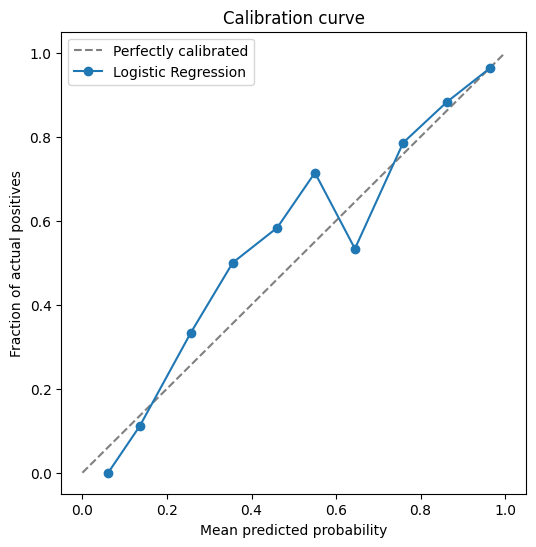

Mean predicted prob per bin: [0.06091097 0.13568228 0.25643307 0.35557203 0.46076753 0.55000849
 0.64462475 0.75881467 0.86171623 0.96364823]
Actual fraction positive per bin: [0.         0.11111111 0.33333333 0.5        0.58333333 0.71428571
 0.53333333 0.78571429 0.88235294 0.96296296]


In [109]:
## Calibration curve, logistic regression

probs = clf_lr.predict_proba(Xc_test)[:, 1]  # predicted probability of "distinction"

frac_pos, mean_pred = calibration_curve(yc_test, probs, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.plot(mean_pred, frac_pos, marker="o", label="Logistic Regression")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of actual positives")
ax.set_title("Calibration curve")
ax.legend()
plt.show()

print("Mean predicted prob per bin:", mean_pred)
print("Actual fraction positive per bin:", frac_pos)

### Calibration Finding

The Logistic Regression model appears **reasonably well calibrated overall**, with most points close to the diagonal, but its calibration is weakest in the **middle probability range around 0.55–0.65**, where predicted probabilities differ noticeably from the actual fraction of positives.